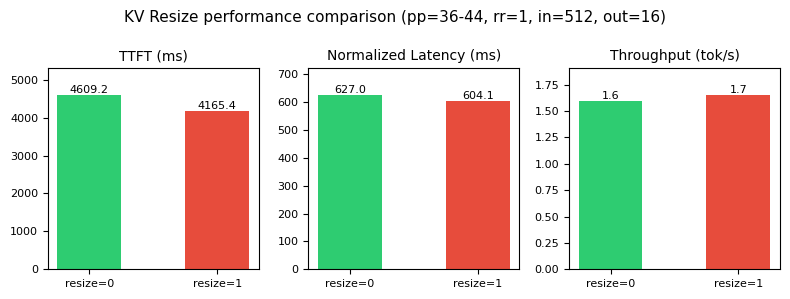

=== 性能指标对比 ===

kv_resize=0:
  TTFT (ms): 4609.16
  Normalized Latency (ms): 627.03
  Throughput (tok/s): 1.59

kv_resize=1:
  TTFT (ms): 4165.39
  Normalized Latency (ms): 604.07
  Throughput (tok/s): 1.66


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 数据路径
BASE_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-resize-test"
resize_0 = f"{BASE_DIR}/test-{{kernel=direct}}-{{pp=36-44}}-{{rr=1}}-{{mig=1}}-{{in=512}}-{{out=16}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{blk=128}}-{{vmm=1}}-{{kv_resize=0}}/request_metrics.csv"
resize_1 = f"{BASE_DIR}/test-{{kernel=direct}}-{{pp=36-44}}-{{rr=1}}-{{mig=1}}-{{in=512}}-{{out=16}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{blk=128}}-{{vmm=1}}-{{kv_resize=1}}/request_metrics.csv"

# 读取数据
df0 = pd.read_csv(resize_0)
df1 = pd.read_csv(resize_1)

# 计算平均指标 (单位转换：秒 -> 毫秒)
output_tokens = 16  # out=16

metrics = {
    'kv_resize=0': {
        'TTFT (ms)': df0['ttfts'].mean() * 1000,
        'Normalized Latency (ms)': df0['e2els'].mean() / output_tokens * 1000,
        'Throughput (tok/s)': output_tokens / df0['e2els'].mean()
    },
    'kv_resize=1': {
        'TTFT (ms)': df1['ttfts'].mean() * 1000,
        'Normalized Latency (ms)': df1['e2els'].mean() / output_tokens * 1000,
        'Throughput (tok/s)': output_tokens / df1['e2els'].mean()
    }
}

# 绘制柱状图 - 更紧凑
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
metric_names = ['TTFT (ms)', 'Normalized Latency (ms)', 'Throughput (tok/s)']
colors = ['#2ecc71', '#e74c3c']
labels = ['resize=0', 'resize=1']
x = np.arange(len(labels))
bar_width = 0.5

for i, metric in enumerate(metric_names):
    values = [metrics['kv_resize=0'][metric], metrics['kv_resize=1'][metric]]
    bars = axes[i].bar(x, values, width=bar_width, color=colors)
    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels, fontsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    
    # 扩展y轴上限，为标签留出空间
    ymax = max(values) * 1.15
    axes[i].set_ylim(0, ymax)
    
    # 添加数值标签
    for bar, val in zip(bars, values):
        axes[i].annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.suptitle('KV Resize performance comparison (pp=36-44, rr=1, in=512, out=16)', fontsize=11)
plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/kv_resize_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印数值
print("=== 性能指标对比 ===")
for config, m in metrics.items():
    print(f"\n{config}:")
    for k, v in m.items():
        print(f"  {k}: {v:.2f}")